In [26]:
from pystac_client import Client


catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox = [78.0, 17.0, 78.03, 17.03], 
    datetime="2023-01-01/2023-01-10",
    query={"eo:cloud_cover": {"lt": 10}}
)

items = list(search.items())[:1]


print(f"Found {len(items)} items")

Found 1 items


In [27]:
import planetary_computer

items = [planetary_computer.sign(item) for item in items]

In [28]:
import odc.stac

data = odc.stac.load(
    items,
    bands=["red", "nir"],
    resolution=10,
    crs="EPSG:32644",
    chunks={"x": 512, "y": 512}
)

print(data)

<xarray.Dataset> Size: 1GB
Dimensions:      (y: 11300, x: 11300, time: 1)
Coordinates:
  * y            (y) float64 90kB 1.901e+06 1.901e+06 ... 1.788e+06 1.788e+06
  * x            (x) float64 90kB 1.583e+05 1.583e+05 ... 2.713e+05 2.713e+05
  * time         (time) datetime64[us] 8B 2023-01-08T05:12:09.024000
    spatial_ref  int32 4B 32644
Data variables:
    red          (time, y, x) float32 511MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    nir          (time, y, x) float32 511MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>


In [29]:
ndvi = (data.nir - data.red) / (data.nir + data.red + 1e-6)

In [30]:
ndvi_small = ndvi.isel(time=0)
ndvi_small.compute()

<xarray.DataArray (y: 11300, x: 11300)> Size: 511MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(11300, 11300), dtype=float32)
Coordinates:
  * y            (y) float64 90kB 1.901e+06 1.901e+06 ... 1.788e+06 1.788e+06
  * x            (x) float64 90kB 1.583e+05 1.583e+05 ... 2.713e+05 2.713e+05
    spatial_ref  int32 4B 32644
    time         datetime64[us] 8B 2023-01-08T05:12:09.024000

Items found: 2
<xarray.Dataset> Size: 2GB
Dimensions:      (y: 11300, x: 11300, time: 2)
Coordinates:
  * y            (y) float64 90kB 1.901e+06 1.901e+06 ... 1.788e+06 1.788e+06
  * x            (x) float64 90kB 1.583e+05 1.583e+05 ... 2.713e+05 2.713e+05
  * time         (time) datetime64[us] 16B 2023-01-03T05:12:21.024000 2023-01...
    spatial_ref  int32 4B 32644
Data variables:
    red          (time, y, x) float32 1GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    nir          (time, y, x) float32 1GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
Red min/max: 881.0 20432.0
NIR min/max: 782.0 18624.0
Starting compute...
Compute done!


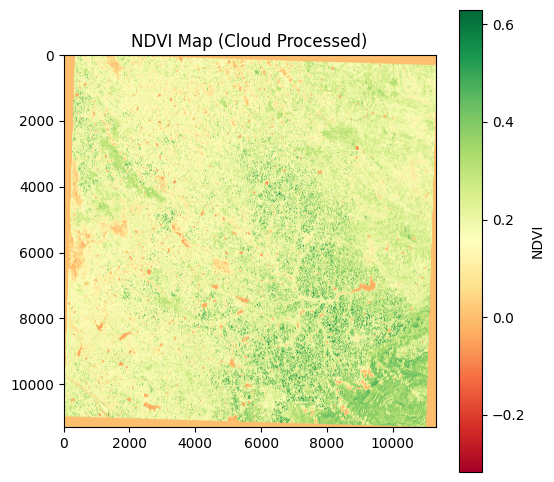

In [31]:
# -------------------------
# IMPORTS
# -------------------------
from pystac_client import Client
import planetary_computer
import odc.stac
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# STEP 1: CONNECT TO STAC
# -------------------------

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

# -------------------------
# STEP 2: DEFINE QUERY
# -------------------------

bbox = [78.0, 17.0, 78.03, 17.03]  # SMALL area (important)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2023-01-01/2023-01-10",
    query={"eo:cloud_cover": {"lt": 5}}  # strict cloud filter
)

items = list(search.get_items())[:2]  # LIMIT DATA

print(f"Items found: {len(items)}")

# -------------------------
# STEP 3: SIGN DATA
# -------------------------

items = [planetary_computer.sign(item) for item in items]

# -------------------------
# STEP 4: LOAD DATA CUBE
# -------------------------

data = odc.stac.load(
    items,
    bands=["red", "nir"],
    resolution=10,
    crs="EPSG:32644",
    chunks={"x": 512, "y": 512}  # critical for performance
)

print(data)

# -------------------------
# STEP 5: VALIDATE DATA
# -------------------------

print("Red min/max:", float(data.red.min()), float(data.red.max()))
print("NIR min/max:", float(data.nir.min()), float(data.nir.max()))

# -------------------------
# STEP 6: SAFE NDVI
# -------------------------

ndvi = (data.nir - data.red) / (data.nir + data.red + 1e-6)

# Mask invalid pixels
valid_mask = (data.red > 0) & (data.nir > 0)
ndvi = ndvi.where(valid_mask)

# -------------------------
# STEP 7: COMPUTE (CONTROLLED)
# -------------------------

ndvi_slice = ndvi.isel(time=0)  # ONLY ONE TIME STEP

print("Starting compute...")
ndvi_computed = ndvi_slice.compute()
print("Compute done!")

# -------------------------
# STEP 8: CLEAN DATA
# -------------------------

ndvi_clean = ndvi_computed.fillna(0)

# -------------------------
# STEP 9: VISUALIZE
# -------------------------

plt.figure(figsize=(6,6))
plt.imshow(ndvi_clean, cmap="RdYlGn")
plt.colorbar(label="NDVI")
plt.title("NDVI Map (Cloud Processed)")
plt.show()